# Monte Carlo Simulation of Stock Prices with Intrinsic Value Analysis

This Jupyter Notebook provides a framework to perform a Monte Carlo simulation for predicting the future price of a stock. The simulation leverages historical stock price data to calculate key financial statistics and generate potential price trajectories over a specified time horizon. Additionally, the notebook calculates the intrinsic value of the stock based on growth rates and valuation metrics.

## Constants

NUM_OF_SIMULATIONS: Number of Monte Carlo simulation iterations

SIMULATION_DAYS: Number of trading days in the simulation (default: 252)

## Functions

#### download_data(stocks, start, end)
Purpose: Downloads historical closing price data for the specified stocks within a given date range.

Inputs:
- stocks: Stock tickers
- start: Start date of the data range
- end: End date of the data range

Output: DataFrame containing the historical closing prices.

#### calculate_statistics(daily_returns)

Purpose: Calculates mean and standard deviation of daily returns for a stock.

Inputs: 
- daily_returns: DataFrame of daily percentage changes.

Outputs: Mean (mu) and standard deviation (sigma) of the daily returns.

#### stock_monte_carlo_vectorized(S0, mu, sigma, growth_5=0, growth_10=0, N=252, num_simulations=100000, discount_rate=0.1)

Purpose: Performs the Monte Carlo simulation to predict stock prices and calculates the intrinsic value of the stock.

Inputs:
- S0: Current stock price
- mu: Expected daily return (mean)
- sigma: Daily return volatility (standard deviation)
- growth_5: Annual growth rate for the first 5 years
- growth_10: Annual growth rate for years 6–10
- N: Number of simulation days (default: 252)
- num_simulations: Number of Monte Carlo iterations (default: 100,000)
- discount_rate: Discount rate for intrinsic value calculation

Outputs: Plots stock price simulations and intrinsic value analysis.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import datetime

NUM_OF_SIMULATIONS = 200000
SIMULATION_DAYS = 252

def download_data(stocks, start, end):

    stock_data = {}
    for stock in stocks:
        ticker = yf.Ticker(stock)
        history = ticker.history(start=start, end=end)
        if history.empty:
            raise ValueError(f"No data found for stock: {stock}")
        stock_data[stock] = history['Close']
    return pd.DataFrame(stock_data)

def calculate_statistics(daily_returns):

    mu = daily_returns.mean().iloc[0]
    sigma = daily_returns.std().iloc[0]
    return mu, sigma

def stock_monte_carlo_vectorized(S0, mu, sigma, growth_5=0, growth_10=0, N=252, num_simulations=100000, discount_rate=0.1):
    
    # Generate random daily returns
    daily_returns = np.random.normal(mu, sigma, (num_simulations, N))
    
    # Calculate cumulative returns
    cumulative_returns = np.cumprod(1 + daily_returns, axis=1)
    
    # Calculate price paths
    price_paths = S0 * cumulative_returns
    
    # Append the initial price to each path
    price_paths = np.hstack((np.full((num_simulations, 1), S0), price_paths))
    
    # Calculate statistics
    mean_simulation = price_paths.mean(axis=0)
    percentile_5 = np.percentile(price_paths, 5, axis=0)
    percentile_95 = np.percentile(price_paths, 95, axis=0)
    # Intrinsic Value
    ticker = yf.Ticker(stocks[0])
    info = ticker.info
    if isinstance((info.get('trailingEps')),(int, float)):
        try: 
            eps = info.get('trailingEps')
            tv = info.get('trailingPE') * 0.9
            intrinsic_value, eps_val = 0, eps
            for year in range(1, 11):
                eps_val *= (1 + growth_5 if year <= 5 else 1 + growth_10)
                intrinsic_value += eps_val / ((1 + discount_rate) ** year)
            intrinsic_value = round(intrinsic_value + (eps_val * tv) / ((1 + discount_rate) ** 10), 2)
            mos = round(0.8*intrinsic_value,2)
            
        except Exception as e:
            print(e)
    
    # Plot the results
    plt.figure(figsize=(10, 5))
    plt.plot(mean_simulation, label='Mean Simulation', color='blue')
    try:
        plt.hlines(intrinsic_value, xmin=0, xmax=N, colors='red', label = 'Intrinsic Value')
        plt.hlines(mos, xmin=0, xmax=N, colors='orange', label = 'Margin of Safety')
    except:
        pass
    plt.fill_between(range(N+1), percentile_5, percentile_95, color='gray', alpha=0.2, label='5th-95th Percentile')
    plt.title(f'Monte Carlo Simulation of {stocks[0].upper()} Stock Price')
    plt.xlabel('Days')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid(True)
    plt.show()
    try:
        print("Intrinsic Value: ", f"${intrinsic_value}")
        print("MOS Price: ", f"${mos}")
        print("Potential Upside: ", f"{round(((intrinsic_value-current_price)/current_price) * 100,2)}%" )
    except:
        pass
    print(f'Prediction for future stock price (Mean): ${mean_simulation[-1]:.2f}')
    print(f'5th Percentile: ${percentile_5[-1]:.2f}')
    print(f'95th Percentile: ${percentile_95[-1]:.2f}')
    print(f'% Change from current price (Mean): {round(((mean_simulation[-1] - current_price)/current_price)*100, 2)}%')
    print(f'% Change from current price (5th Percentile): {round(((percentile_5[-1] - current_price)/current_price)*100, 2)}%')
    print(f'% Change from current price (95th Percentile): {round(((percentile_95[-1] - current_price)/current_price)*100, 2)}%')

# Usage Example

1. Specify stock ticker, start and end dates for historical data
2. Fetch stock data using download_data
3. Calculate statistics using calculate_statistics
4. Run stock_monte_carlo_vectorized with appropriate parameters to simulate stock price movements and intrinsic value

Current Price of GOOG: $197.57
Mean Daily Return (mu): 0.000823
Daily Return Standard Deviation (sigma): 0.017234


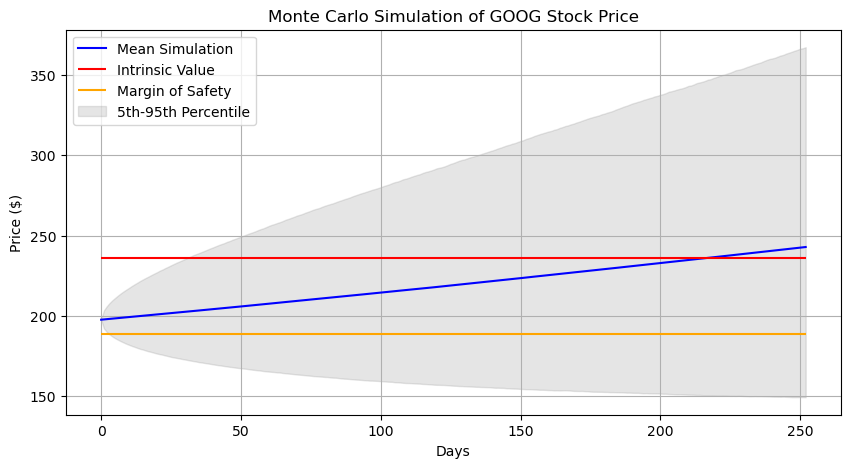

Intrinsic Value:  $235.72
MOS Price:  $188.58
Potential Upside:  19.31%
Prediction for future stock price (Mean): $242.86
5th Percentile: $149.25
95th Percentile: $367.39
% Change from current price (Mean): 22.92%
% Change from current price (5th Percentile): -24.46%
% Change from current price (95th Percentile): 85.95%
CPU times: total: 3.75 s
Wall time: 3.84 s


In [6]:
%%time
start = '2010-01-01'
end = datetime.datetime.today().strftime('%Y-%m-%d')
stocks = ['goog']  
data = download_data(stocks, start, end)
daily_returns = data.pct_change().dropna()
mu, sigma = calculate_statistics(daily_returns)
current_price = data[stocks[0]].iloc[-1]

print(f"Current Price of {stocks[0].upper()}: ${current_price:.2f}")
print(f"Mean Daily Return (mu): {mu:.6f}")
print(f"Daily Return Standard Deviation (sigma): {sigma:.6f}")

stock_monte_carlo_vectorized(current_price, mu, sigma, 0.10, 0.08, N=SIMULATION_DAYS, num_simulations=NUM_OF_SIMULATIONS)